# KNN on iris dataset
- alternative. source kaggle.com

### https://www.kaggle.com/code/skalskip/iris-data-visualization-and-knn-classification

In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris

In [3]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns= iris.feature_names)
df = pd.concat([df, pd.DataFrame(iris.target, columns= ["iris_species"])], axis = 1)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),iris_species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### Initial EDA

In [4]:
df.shape

(150, 5)

In [5]:
df.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),iris_species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [6]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),iris_species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [8]:
df.groupby("iris_species").size()

iris_species
0    50
1    50
2    50
dtype: int64

In [9]:
feature_columns = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)','petal width (cm)']
X = df[feature_columns].values
y = df['iris_species'].values

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.5, random_state = 42)

### KNN

### Predict

In [13]:
# Fitting clasifier to the Training set
# Loading libraries
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import cross_val_score

# Instantiate learning model (k = 3)
classifier = KNeighborsClassifier(n_neighbors=3)

# Fitting the model
classifier.fit(X_train, y_train)

# Predicting the Test set results
y_pred = classifier.predict(X_test)
y_pred

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 1, 0, 0, 2, 1, 0, 0, 0, 2, 1, 1, 0,
       0, 1, 1, 2, 1, 2, 1, 2, 1, 0, 2, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0,
       1, 2, 0, 1, 2, 0, 2, 2, 1])

### Evaluate

In [15]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[29,  0,  0],
       [ 0, 23,  0],
       [ 0,  2, 21]])

### Calculate accuracy

In [21]:
accuracy = accuracy_score(y_test, y_pred) * 100
print("Accuracy of model is equal " + str(round(accuracy, 2)) + "%")

Accuracy of model is equal 97.33%


### Parameter tuning using cross validation

In [23]:
# create list of K for KNN

k_list = list(range(1, 50, 2))
cv_scores = []

for k in k_list:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=10, scoring='accuracy')
    cv_scores.append(scores.mean())
print(cv_scores)

[np.float64(0.9214285714285714), np.float64(0.9214285714285714), np.float64(0.9089285714285713), np.float64(0.9339285714285716), np.float64(0.9339285714285716), np.float64(0.9357142857142857), np.float64(0.9089285714285715), np.float64(0.9214285714285715), np.float64(0.9357142857142857), np.float64(0.9607142857142857), np.float64(0.9196428571428573), np.float64(0.9196428571428573), np.float64(0.9071428571428573), np.float64(0.9071428571428573), np.float64(0.9071428571428573), np.float64(0.9071428571428573), np.float64(0.9071428571428573), np.float64(0.9071428571428573), np.float64(0.9071428571428573), np.float64(0.8017857142857142), np.float64(0.6821428571428572), np.float64(0.5732142857142857), np.float64(0.5732142857142857), np.float64(0.575), np.float64(0.3875)]


### Plot

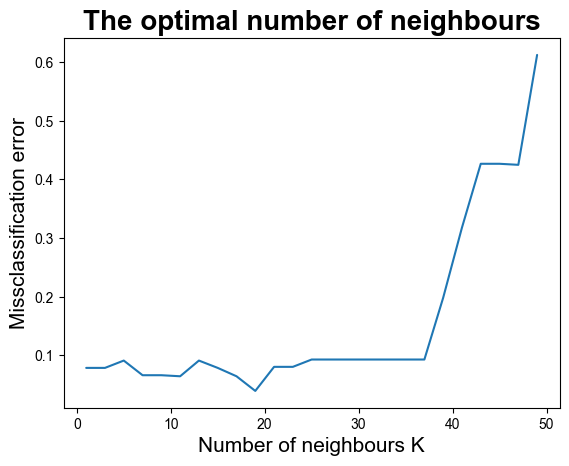

In [24]:
MSE= [1 - x for x in cv_scores]

plt.figure()
plt.title("The optimal number of neighbours", fontsize=20, fontweight='bold')
plt.xlabel("Number of neighbours K", fontsize=15)
plt.ylabel("Missclassification error", fontsize=15)
sns.set_style("whitegrid")
plt.plot(k_list, MSE)

plt.show()

In [25]:
# find best K
best_k = k_list[MSE.index(min(MSE))]
print("The optimal number of neighbours is %d" % best_k)

The optimal number of neighbours is 19
